This notebook investigates whether the GDP per capita of countries have any association with ICE removals over time. We have limitations on the data accessible to us thus, we will be making an assumption that a persons departure country (contained in the ice dataset) is their country of origin.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
gdp = pd.read_csv('API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv', skiprows=4)

print(gdp.head())

                  Country Name Country Code                Indicator Name  \
0                        Aruba          ABW  GDP per capita (current US$)   
1  Africa Eastern and Southern          AFE  GDP per capita (current US$)   
2                  Afghanistan          AFG  GDP per capita (current US$)   
3   Africa Western and Central          AFW  GDP per capita (current US$)   
4                       Angola          AGO  GDP per capita (current US$)   

   Indicator Code        1960        1961        1962        1963        1964  \
0  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
1  NY.GDP.PCAP.CD  186.089204  186.909053  197.367547  225.400079  208.962717   
2  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
3  NY.GDP.PCAP.CD  121.936832  127.451040  133.823783  139.004980  148.545883   
4  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   

         1965  ...          2017          2018    

In [3]:
#ensures we format data by country
gdp_long = gdp.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(y) for y in range(2010, 2024)],
    var_name='year',
    value_name='gdp_per_capita'
)

gdp_long['year'] = gdp_long['year'].astype(int)
gdp_long = gdp_long.dropna(subset=['gdp_per_capita'])
gdp_long.columns = ['country_name', 'country_code', 'year', 'gdp_per_capita']

print(gdp_long.head())

                  country_name country_code  year  gdp_per_capita
0                        Aruba          ABW  2010    24093.140151
1  Africa Eastern and Southern          AFE  2010     1628.905248
2                  Afghanistan          AFG  2010      560.621505
3   Africa Western and Central          AFW  2010     1662.633658
4                       Angola          AGO  2010     4101.637156


In [4]:
removals = pd.read_csv('removals_10yr.csv', usecols=['Departure Country', 'Departure Date'])

removals['year'] = pd.to_datetime(removals['Departure Date'], errors='coerce').dt.year

removals_by_country = removals.groupby(['Departure Country', 'year']).size().reset_index(name='removal_count')

print(removals_by_country.head())

  Departure Country  year  removal_count
0       AFGHANISTAN  2011              3
1       AFGHANISTAN  2012              6
2       AFGHANISTAN  2013              1
3       AFGHANISTAN  2014              1
4       AFGHANISTAN  2015              2


In [5]:
#join both the gdp and removals dataset
removals_by_country['country_name'] = removals_by_country['Departure Country'].str.title()

merged_gdp = pd.merge(
    removals_by_country,
    gdp_long,
    on=['country_name', 'year'],
    how='inner'
)

print(merged_gdp.shape)
print(merged_gdp.head())

(1227, 6)
  Departure Country  year  removal_count country_name country_code  \
0       AFGHANISTAN  2011              3  Afghanistan          AFG   
1       AFGHANISTAN  2012              6  Afghanistan          AFG   
2       AFGHANISTAN  2013              1  Afghanistan          AFG   
3       AFGHANISTAN  2014              1  Afghanistan          AFG   
4       AFGHANISTAN  2015              2  Afghanistan          AFG   

   gdp_per_capita  
0      606.694676  
1      651.417134  
2      637.087099  
3      625.054942  
4      565.569730  


In [6]:
top10 = merged_gdp.groupby('country_name').agg(
    total_removals=('removal_count', 'sum'),
    avg_gdp=('gdp_per_capita', 'mean')
).nlargest(10, 'total_removals').reset_index()

print(top10)

         country_name  total_removals       avg_gdp
0              Mexico           53253  10217.719766
1         El Salvador           13663   3902.914855
2            Honduras           11759   2314.726675
3           Guatemala           10328   4011.157443
4              Brazil            3640  10171.131672
5  Dominican Republic            2890   7052.343931
6              Canada            2059  48077.054150
7            Colombia            1815   6865.055943
8             Jamaica            1782   5441.104558
9             Ecuador            1574   5951.266427


These are the top 10 countries with the most removals and their corresponding average gdp per capita. Mexico is leading with upwards of a million removals.

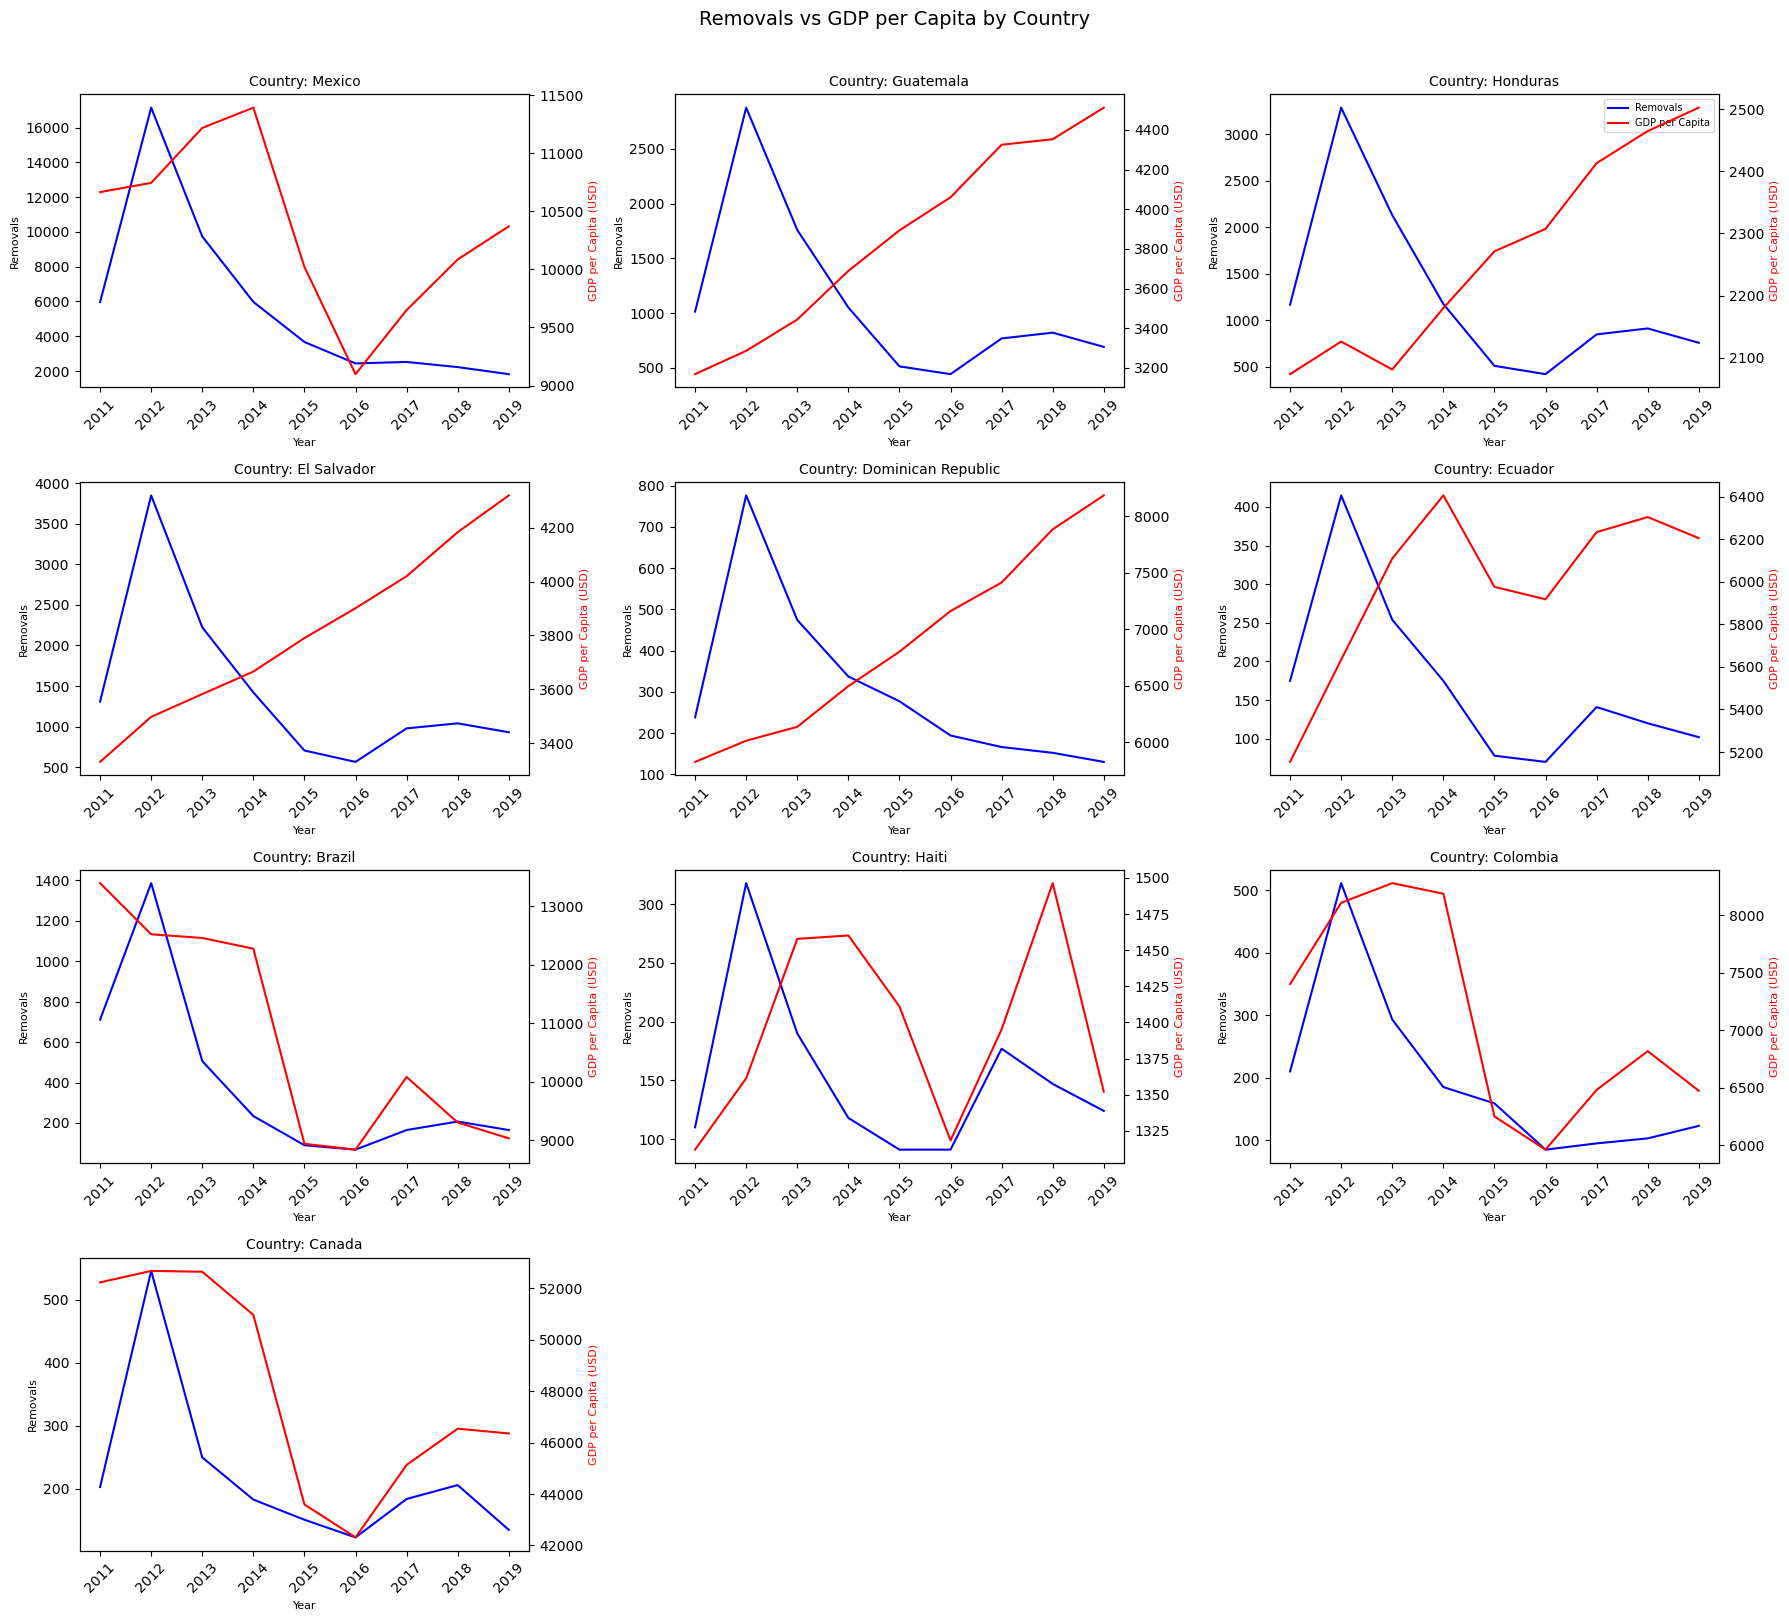

In [12]:
countries = ['Mexico', 'Guatemala', 'Honduras', 'El Salvador', 'Dominican Republic', 
             'Ecuador', 'Brazil', 'Haiti', 'Colombia', 'Canada']

exclude_years = [2020, 2021]

n_cols = 3
n_rows = (len(countries) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, country_name in enumerate(countries):
    subset = merged_gdp[merged_gdp['country_name'] == country_name].sort_values('year')
    subset = subset[~subset['year'].isin(exclude_years)]

    ax1 = axes[i]
    ax2 = ax1.twinx()

    ax1.plot(subset['year'], subset['removal_count'], label='Removals', color='blue')
    ax2.plot(subset['year'], subset['gdp_per_capita'], color='red', label='GDP per Capita')

    ax1.set_title(f'Country: {country_name}', fontsize=10)
    ax1.set_xlabel('Year', fontsize=8)
    ax1.set_ylabel('Removals', fontsize=8)
    ax2.set_ylabel('GDP per Capita (USD)', color='red', fontsize=8)
    ax1.tick_params(axis='x', rotation=45)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    if i == n_cols - 1:
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Removals vs GDP per Capita by Country', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Across the top 10 countries with the highest removals, there are no consistently strong correlations between GDP and removal counts. It also worth noting that a majority of these countries are Latin American, with Mexico leading by a large margin. This could suggest that removal volume may be driven more by georaphic proximity to the US than by economic reasons as there are no consitent correlations.